# Homework 6: Testing Hypotheses

**Reading**: 
* [Testing Hypotheses](https://www.inferentialthinking.com/chapters/11/Testing_Hypotheses.html)

Please complete this notebook by filling in the cells provided. Before you begin, execute the following cell.

Directly sharing answers is not okay, but discussing problems with the course staff or with other students is encouraged. 

For all problems that you must write our explanations and sentences for, you **must** provide your answer in the designated space. Moreover, throughout this homework and all future ones, please be sure to not re-assign variables throughout the notebook! For example, if you use `max_temperature` in your answer to one question, do not reassign it later on.

In [23]:
# Don't change this cell; just run it. 

import numpy as np
from datascience import *

# These lines do some fancy plotting magic.
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')

## 1. Spam Calls


## Part 1: 585 Fun

Dr. McLean gets a lot of spam calls. An area code is defined to be a three digit number from 200-999 inclusive. In reality, many of these area codes are not in use. Of these possible numbers, there are currently 317 geographical US area codes and 18 non-geographical US area codes, for a total of 335. 

**Throughout these questions, you should assume that Dr. McLean's area code is 585 (Rochester NY, home of the [garbage plate](https://www.visitrochester.com/blog/post/rochester-garbage-plate/)).**

**Question 1.1.** Assuming that each US area code is just as likely as any other, what is the probability that the area code of four consecutive spam calls is 585? Assign this value to `prob_585`.

In [24]:
prob_585 = (1 / 335) ** 4
prob_585

7.940004925780556e-11

**Question 1.2.** Peter already knows that Dr. McLean's area code is 585. From googling, Peter determines that there are 792 possible prefixes (the next three digits after the area code) for any area code and randomly guesses one of those prefixes and the last 4 digits (0-9 inclusive) of Dr. McLean's phone number. What's the probability that Peter correctly guesses Dr. McLean's number, assuming that he’s equally likely to choose any prefix or digit? 

*Note: A phone number contains an area code and 7 additional digits, i.e. xxx-xxx-xxxx*

In [25]:
prob_mclean_num = (1 / 792) * (1 / 10**4)
prob_mclean_num

1.262626262626263e-07

Dr. McLean suspects that there's a higher chance that the spammers are using his area code (585) to trick him into thinking it's someone from his area calling him. Stephanie thinks that this is not the case, and that spammers are just choosing area codes of the spam calls at random from all possible US area codes. Dr. McLean wants to test his claim using the 50 spam calls he received in the past month.

Here's a dataset of the area codes of the 50 spam calls he received in the past month.

In [26]:
# Just run this cell
spam = Table().read_table('../../shared/Data/spam.csv')
spam

Area Code
810
630
205
440
585
304
870
610
717
332


**Question 1.3.** Define the null hypothesis and alternative hypothesis for this investigation. 

*Hint: Don’t forget that your null hypothesis should fully describe a probability model that we can use for simulation later.*

Null Hypothesis: Spammers choose area codes uniformly at random from all 335 valid US area codes. Each area code, including 585, has an equal chance 1/335 of being chosen for any call. Any difference between the sample proportion of 585 calls and 1/335 is due purely to chance. 
Alternative Hypothesis: Spammers are deliberately targeting Dr. McLean by choosing his area code (585) more frequently than expected by random chance (the probability of getting 585 is greater than 1/335).

**Question 1.4.** Which of the following test statistics would help differentiate between the two hypotheses?

*Hint*: For a refresher on choosing test statistics, check out the textbook section on [Test Statistics](https://inferentialthinking.com/chapters/11/3/Decisions_and_Uncertainty.html#step-2-the-test-statistic).

1. The proportion of area codes that are 585 in 50 random spam calls
2. The probability of getting an area code of 585 out of all the possible area codes.
3. The proportion of area codes that are 585 in 50 random spam calls divided by 2
4. The number of times you see the area code 585 in 50 random spam calls

Assign `reasonable_test_statistics` to an array of numbers corresponding to these test statistics.

In [27]:
reasonable_test_statistics = make_array(1, 3, 4)

**For the rest of this question, suppose that you decide to use the number of times you see the area code 585 in 50 spam calls as your test statistic.**

**Question 1.5.** 
Write a function called `simulate` that generates exactly one simulated value of your test statistic under the null hypothesis.  It should take no arguments and simulate 50 area codes under the assumption each area code is sampled with equal probability. The `all_area_codes` table contains all US area codes. Your function should return the number of times you saw the 585 area code in those 50 random spam calls.

In [28]:
AreaCodes = Table.read_table('../../shared/Data/all_area_codes.csv')
AreaCodes

Area Code,State
201,NJ
202,DC
203,CT
205,AL
206,WA
207,ME
208,ID
209,CA
210,TX
212,NY


In [29]:
def simulate():
    simulated_calls = AreaCodes.sample(50)
    return np.count_nonzero(simulated_calls.column(0) == 585)

# Call your function to make sure it works
simulate()

0

**Question 1.6.** Generate 20,000 simulated values of the number of times you see the area code 585 in 50 random spam calls. Assign `test_statistics_under_null` to an array that stores the result of each of these trials. 

*Hint*: Use the function you defined in Question 5.

In [30]:
test_statistics_under_null = make_array()
repetitions = 20000

for i in np.arange(repetitions):
    test_statistics_under_null = np.append(test_statistics_under_null, simulate())
    
test_statistics_under_null

array([ 0.,  0.,  0., ...,  0.,  0.,  0.])

**Question 1.7.** Using the results from Question 6, generate a histogram of the empirical distribution of the number of times you saw the area code 585 in your simulation. **NOTE: Use the provided bins when making the histogram**

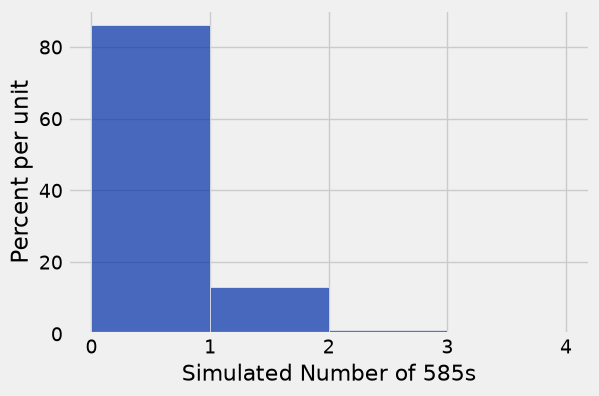

In [31]:
bins = np.arange(0, 5, 1) # Use these provided bins
Table().with_column("Simulated Number of 585s", test_statistics_under_null).hist(bins=bins)

**Question 1.8.** Compute an empirical P-value for this test.

In [32]:
# First calculate the observed value of the test statistic from the `spam` table.
observed_val = spam.where("Area Code", 585).num_rows
p_value = np.count_nonzero(test_statistics_under_null >= observed_val) / repetitions
p_value

0.0101

**Question 1.9.** Suppose you use a P-value cutoff of 1%. What do you conclude from the hypothesis test? Why?

We reject the null hypothesis. The empirical P-value is well below the 1% significance threshold. Getting the observed number of 585 area codes purely by chance is very unlikely. This provides strong evidence that spam callers are favoring Dr. McLean's area code.

## Part 2: Multiple Spammers

Instead of checking if the area code is equal to his own, Dr. McLean decides to check if the area code matches the area code of one of the seven places he's been to recently, and wants to test if it's more likely to receive a spam call with an area code from any of those seven places. These are the area codes of the places he's been to recently: 585, 919, 910, 315, 336, 775, 720.

**Question 2.1.** Define the null hypothesis and alternative hypothesis for this investigation.

*Reminder: Don’t forget that your null hypothesis should fully describe a probability model that we can use for simulation later.*



Null Hypothesis: Spammers choose area codes uniformly at random from all 335 valid US area codes. The chance of receiving a call from any of the 7 visited area codes is 7/335 for each call, and any variation is due to chance.
Alternative Hypothesis: Spammers are more likely to use area codes from the 7 locations Dr. McLean has visited (the probability of receiving a call from one of these 7 area codes is greater than 7/335).

**Suppose you decide to use the number of times you see any of the area codes of the places Dr. McLean has been to in 50 spam calls as your test statistic.**

**Question 2.2.** Write a function called `simulate_visited_area_codes` that generates exactly one simulated value of your test statistic under the null hypothesis. It should take no arguments and return the number of times that you saw any of the area codes of the places Dr. McLean has been to in those 50 spam calls (under the assumption that the calls come from the US area codes with equal probability).
 

*Hint*: You may find the textbook [section](https://inferentialthinking.com/chapters/11/1/Assessing_a_Model.html#simulating-one-value-of-the-statistic) on the `sample_proportions` function to be useful.

In [33]:
model_proportions = make_array(7 / 335, 328 / 335)

def simulate_visited_area_codes():
    return sample_proportions(50, model_proportions).item(0) * 50
    
# Call your function to make sure it works
simulate_visited_area_codes()

1.0

**Question 2.3.** Generate 20,000 simulated values of the number of times you see any of the area codes of the places Dr. McLean has been to in 50 random spam calls. Assign `test_statistics_under_null` to an array that stores the result of each of these trials. 

*Hint*: Use the function you defined in Question 2.2

In [34]:
visited_test_statistics_under_null = make_array()

repetitions = 20000
for i in np.arange(repetitions):
    visited_test_statistics_under_null = np.append(
        visited_test_statistics_under_null, 
        simulate_visited_area_codes()
    )

visited_test_statistics_under_null

array([ 1.,  4.,  1., ...,  0.,  0.,  1.])

**Question 2.4.** Using the results from Question 2.3, generate a histogram of the empirical distribution of the number of times you saw any of the area codes of the places Dr. McLean has been to in your simulation. **NOTE: Use the provided bins when making the histogram**

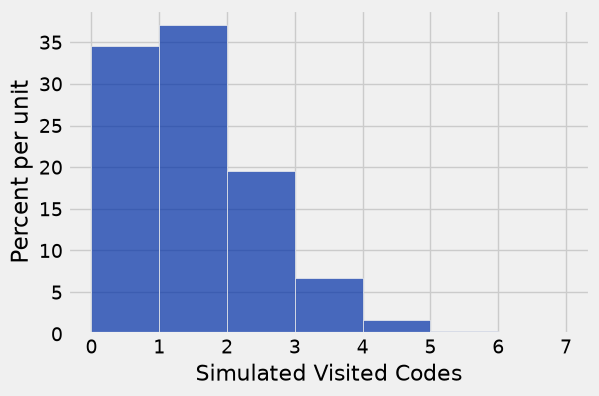

In [35]:
bins_visited = np.arange(0, 8, 1) # Use these provided bins
Table().with_column("Simulated Visited Codes", visited_test_statistics_under_null).hist(bins=bins_visited)

**Question 2.5** Compute an empirical P-value for this test.

In [36]:
# First calculate the observed value of the test statistic from the `spam` table.
visited_area_codes = make_array(585, 919, 910, 315, 336, 775, 720)
visited_observed_value = spam.where("Area Code", are.contained_in(visited_area_codes)).num_rows
p_value = np.count_nonzero(visited_test_statistics_under_null >= visited_observed_value) / repetitions
p_value

0.0037499999999999999

**Question 2.6.** Suppose you use a P-value cutoff of 0.5% (**Note: that’s 0.5%, not our usual cutoff of 5%**). What do you conclude from the hypothesis test? Why?

We reject the null hypothesis. The empirical P-value is less than the 0.5% cutoff p < 0.005. The observed count of spam calls from visited area codes is significantly greater than what would reasonably occur by random sampling from all US area codes.

**Question 2.7.** Is `p_value`:

* (a) the probability that the spam calls favored the visited area codes,
* (b) the probability that they didn't favor, or
* (c) neither

If you chose (c), explain what it is instead.

c. The P-value is neither of those probabilities. It is the probability, assuming the null hypothesis is true, of observing a test statistic as extreme as, or more extreme than, the value observed in the sample (in the direction of the alternative hypothesis).

**Question 2.8.** Is 0.5% (the P-value cutoff):

* (a) the probability that the spam calls favored the visited area codes,
* (b) the probability that they didn't favor, or
* (c) neither

If you chose (c), explain what it is instead.

C. The 0.5% cutoff is the significance level ($\alpha$) chosen before the test. It represents the probability of committing a Type I error: the probability of mistakenly rejecting the null hypothesis when the null hypothesis is actually true.

**Question 2.9.** Suppose you run this test for 400 different people after observing each person's last 50 spam calls. When you reject the null hypothesis for a person, you accuse the spam callers of favoring the area codes that person has visited. If the spam callers were not actually favoring area codes that people have visited, can we compute how many times we will incorrectly accuse the spam callers of favoring area codes that people have visited? If so, what is the number? Explain your answer. Assume a 0.5% P-value cutoff.

We cannot know the exact realized number due to random chance. We can get an estimate though. 
Under the null hypothesis, each independent test has a 0.5% (0.005) probability of incorrectly rejecting the null hypothesis (a Type I error). Across 400 individuals, we expect to make 400 * 0.005 = 2 false accusations.

## Part 3: Practice with A/B Tests

Dr. McLean collects information about this month's spam calls. The table `with_labels` is a sampled table, where the `Area Code Visited` column contains either `"Yes"` or `"No"` which represents whether or not Dr. McLean has visited the location of the area code. The `Picked Up` column is `1` if Dr. McLean picked up and `0` if he did not pick up. Honestly, unless it's Dr. McLean's family calling, He's not answering the phone...

In [37]:
# Just run this cell
with_labels = Table().read_table("../../shared/Data/spam_picked_up.csv")
with_labels

Area Code Visited,Picked Up
No,0
Yes,1
No,1
Yes,0
No,0
No,0
Yes,0
No,1
No,1
No,1


Dr. McLean is going to perform an A/B Test to see whether or not he is more likely to pick up a call from an area code he has visited. Specifically, his null hypothesis is that there is no difference in the distribution of calls he picked up between visited and not visited area codes, with any difference due to chance. His alternative hypothesis is that there is a difference between the two categories, specifically that he thinks that he is more likely to pick up if he has visited the area code. We are going to perform a [permutation test](https://www.inferentialthinking.com/chapters/12/1/AB_Testing.html#Permutation-Test) to test this. Our test statistic will be the difference in proportion of calls picked up between the area codes Dr. McLean visited and the area codes he did not visit.

**Question 3.1.** Complete the `difference_in_proportion` function to have it calculate this test statistic, and use it to find the observed value. The function takes in a sampled table which can be any table that has the same columns as `with_labels`. We'll call `difference_in_proportion` with the sampled table `with_labels` in order to find the observed difference in proportion.

In [38]:
def difference_in_proportion(sample):
    proportions = sample.group("Area Code Visited", np.mean)
    proportion_visited = proportions.where("Area Code Visited", "Yes").column("Picked Up mean").item(0)
    proportion_not_visited = proportions.where("Area Code Visited", "No").column("Picked Up mean").item(0)
    return proportion_visited - proportion_not_visited

observed_diff_proportion = difference_in_proportion(with_labels)
observed_diff_proportion

0.25

**Question 3.2.** To perform a permutation test we shuffle the labels, because our null hypothesis is that the labels don't matter because the distribution of calls he picked up between visited and not visited area codes come from same underlying distribution. The labels in this case is the `"Area Code Visited"` column containing `"Yes"` and `"No"`.

Write a function to shuffle the table and return a test statistic using the function you defined previosuly.

*Hint: To shuffle labels, we sample without replacement and then replace the appropriate column with the new shuffled column.*

In [39]:
def simulate_one_stat():
    shuffled = with_labels.sample(with_replacement=False).column("Area Code Visited")
    original_with_shuffled_labels = with_labels.with_column("Area Code Visited", shuffled)
    return difference_in_proportion(original_with_shuffled_labels)

one_simulated_test_stat = simulate_one_stat() 
one_simulated_test_stat

-0.3933823529411765

**Question 3.3.** Generate 1,000 simulated test statistic values. Assign `test_stats` to an array that stores the result of each of these trials. 

We also provided code that'll generate a histogram for you after generating a 1000 simulated test statistic values.

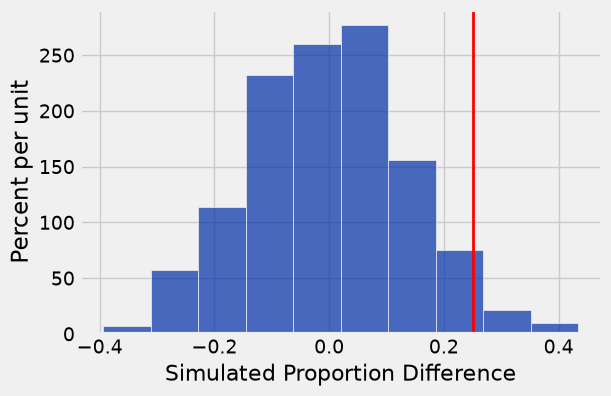

In [40]:
trials = 1000
test_stats = make_array()

for i in np.arange(trials):
    test_stats = np.append(test_stats, simulate_one_stat())

# here's code to generate a histogram of values and the red line is the observed value
Table().with_column("Simulated Proportion Difference", test_stats).hist("Simulated Proportion Difference");
plots.axvline(observed_diff_proportion, color='red', lw=2);

**Question 3.4.** Compute the empirical p-value for this test, and assign it to `p_value_ab`.

In [41]:
p_value_ab = np.count_nonzero(test_stats >= observed_diff_proportion) / trials
p_value_ab

0.087999999999999995